# 00 — Setup and Synthetic Market Data

**Goal:** inspect the inputs used by the rest of the project. The quotes are deliberately synthetic so the notebooks are reproducible and do not depend on a live market-data API.

We use a simple EUR-style teaching setup: short deposits, vanilla swaps and an ATM swaption volatility matrix. The project is intentionally **single-curve** and analyst-level.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import QuantLib as ql

from src.rates_project import *
set_evaluation_date()
print("QuantLib version:", ql.__version__)
print("Evaluation date:", ql.Settings.instance().evaluationDate)

QuantLib version: 1.43
Evaluation date: January 15th, 2026


In [3]:
rate_quotes = pd.read_csv("synthetic_rate_quotes.csv")
rate_quotes

,instrument,tenor,rate
0,Deposit,1M,0.0210
1,Deposit,3M,0.0215
2,Deposit,6M,0.0220
3,Swap,1Y,0.0225
4,Swap,2Y,0.0230
5,Swap,3Y,0.0235
6,Swap,5Y,0.0245
7,Swap,7Y,0.0252
8,Swap,10Y,0.0260


In [5]:
swaption_vols = pd.read_csv("synthetic_swaption_vols.csv")
vol_matrix = swaption_vols.pivot(index="expiry", columns="tenor", values="vol")
vol_matrix

tenor,10Y,1Y,2Y,5Y
expiry,,,,
1Y,0.218,0.235,0.230,0.223
2Y,0.215,0.232,0.227,0.220
5Y,0.208,0.224,0.219,0.213


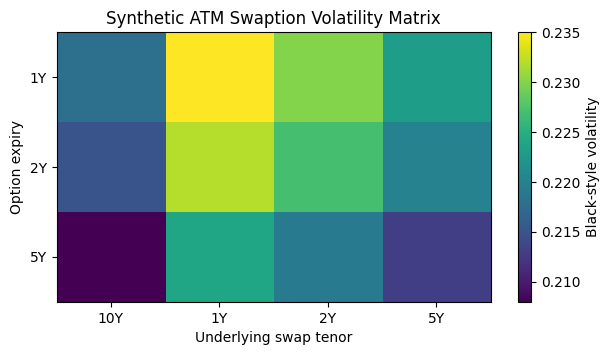

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.5))
im = ax.imshow(vol_matrix.values, aspect="auto")
ax.set_xticks(range(len(vol_matrix.columns)), vol_matrix.columns)
ax.set_yticks(range(len(vol_matrix.index)), vol_matrix.index)
ax.set_xlabel("Underlying swap tenor")
ax.set_ylabel("Option expiry")
ax.set_title("Synthetic ATM Swaption Volatility Matrix")
fig.colorbar(im, ax=ax, label="Black-style volatility")
plt.show()